In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# loading utility files

from utility.sv_fig import savefig
from utility.mi_score import MI_score


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
data = pd.read_csv('data/Xy_Yes_No_md.csv')

print(data.shape)

(74, 16)


In [4]:

data = data.rename(columns={'Age_at_Surgery': 'Age at Surgery'})
data = data.rename(columns={'cT_or_pT': 'cT or pT'})
data = data.rename(columns={'Bx_Histology': 'Bx Histology'})
data = data.rename(columns={'Sample_weight': 'Sample weight'})
data = data.rename(columns={'Tumor_digest_count': 'Tumor digest count'})
data = data.rename(columns={'Fragments_plated': 'Fragments plated'})

In [5]:
# MI

# Data
X = data.drop(columns=['OverallTILGrowth'])
y = data['OverallTILGrowth']

mi_scores = MI_score(X,y)

mi_df = pd.DataFrame(
    {
        "MI_mean": mi_scores.mean(axis=0),
        "MI_std": mi_scores.std(axis=0),
    },
    index=X.columns
).sort_values("MI_mean", ascending=False)

print("\n Cross-Validated Mutual Information Feature Ranking ")
print(mi_df.round(10))


 Cross-Validated Mutual Information Feature Ranking 
                     MI_mean    MI_std
Fragments plated    0.109663  0.075652
Tumor digest count  0.065420  0.040641
Bx Histology        0.065409  0.050949
pN                  0.045488  0.041837
Sample weight       0.042934  0.045163
Age at Surgery      0.033431  0.029295
Smoker              0.031928  0.044425
NAC                 0.025905  0.029325
Race                0.022117  0.044234
Surgery             0.020075  0.040149
BMI                 0.015304  0.020096
pT                  0.011997  0.023994
cT                  0.007920  0.015840
Histology           0.005860  0.011720
cT or pT            0.004574  0.009148


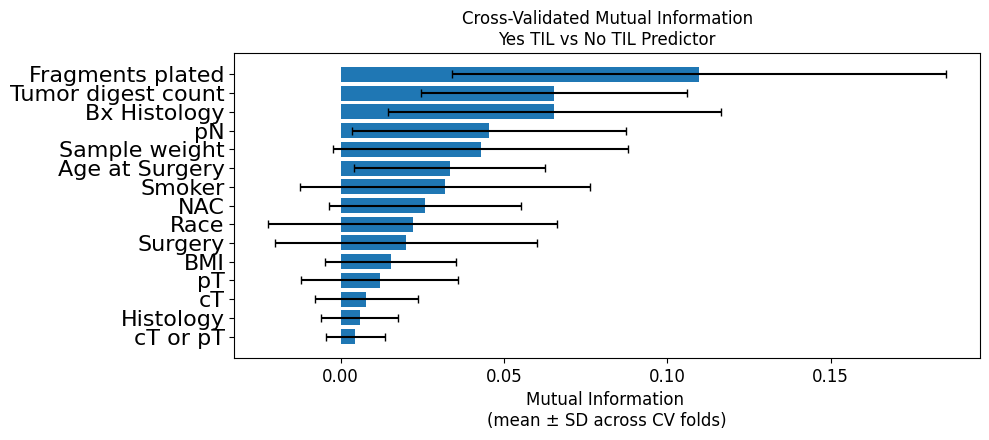

In [6]:
# Plot CV Mutual Information (mean ± std)
mi_plot = mi_df.sort_values("MI_mean")

plt.figure(figsize=(10, max(4, 0.3 * len(mi_plot))))

plt.barh(
    mi_plot.index,
    mi_plot["MI_mean"],
    xerr=mi_plot["MI_std"],
    capsize=3
)

plt.yticks(fontsize=16)
plt.xticks(fontsize=12) 

plt.xlabel("Mutual Information \n(mean ± SD across CV folds)", fontsize=12)
plt.title("Cross-Validated Mutual Information\nYes TIL vs No TIL Predictor", fontsize=12)
plt.tight_layout()

savefig("./figs/Yes_No_MI")
# plt.show()
